2026-01-03 18:03:41,655 - logger - INFO - Provided selected_features parameter is None - all features from dataset will be used.
2026-01-03 18:03:41,655 - logger - INFO - Number of selected features: 24
2026-01-03 18:03:41,660 - logger - INFO - Found 26 participants recorded once.
2026-01-03 18:03:41,661 - logger - DEBUG - Participants recorded once: [1, 16, 24, 23, 22, 21, 20, 18, 2, 17, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 32, 19, 25]
2026-01-03 18:03:41,661 - logger - INFO - Found 6 participants recorded twice.
2026-01-03 18:03:41,662 - logger - DEBUG - Participants recorded twice: [31, 30, 29, 28, 27, 26]
2026-01-03 18:03:41,662 - logger - INFO - Training iteration 1/5
2026-01-03 18:03:41,790 - logger - INFO - Train and test datasets created successfully
2026-01-03 18:03:41,791 - logger - INFO - Train dataset size: 570
2026-01-03 18:03:41,792 - logger - INFO - Test dataset size: 66
2026-01-03 18:03:44,357 - logger - INFO - Siamese neural network model training started...
20

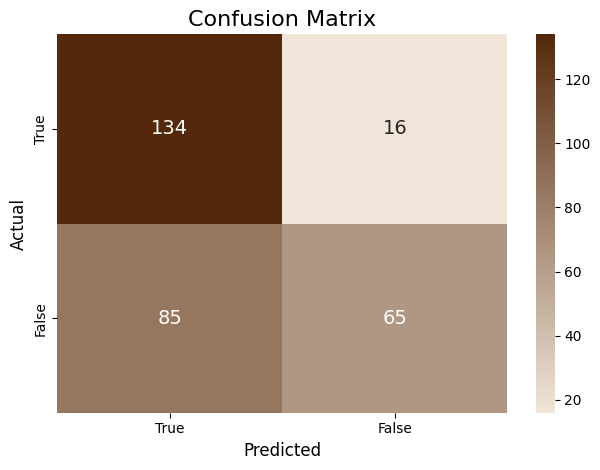

(0.6633333333333333, 0.6118721461187214, 0.8933333333333333)


In [1]:
import pandas as pd
from utils.cross_validation_siamese import CVTrainer

gait_df = pd.read_csv('./datasets/triangulation_gait_features.csv')
cv_trainer = CVTrainer(gait_df)
results = cv_trainer.run_training(n_epochs=10, learning_rate=0.0001, batch_size=4, criterion_type='cosine')
print(results)

In [3]:
import itertools
import logging
import pandas as pd
from utils.cross_validation_siamese import CVTrainer

gait_df = pd.read_csv('./datasets/triangulation_gait_features.csv')
cv_trainer = CVTrainer(dataset=gait_df, log_level=logging.CRITICAL)

n_epochs_values = [5, 10, 15, 20]
learning_rate_values = [1e-3, 1e-4, 1e-5]
batch_size_values = [2, 4, 8, 16, 32, 64]

results = []

param_grid = list(itertools.product(
    n_epochs_values,
    learning_rate_values,
    batch_size_values
))

total_runs = len(param_grid)
results = []

for i, (n_epochs, lr, batch_size) in enumerate(param_grid, start=1):
    print(f"[{i}/{total_runs}] epochs={n_epochs}, lr={lr}, batch_size={batch_size}")
    accuracy, precision, recall = cv_trainer.run_training(
        n_epochs=n_epochs,
        learning_rate=lr,
        batch_size=batch_size,
        show_plot=False,
        criterion_type='cosine',
    )

    results.append({
        "n_epochs": n_epochs,
        "learning_rate": lr,
        "batch_size": batch_size,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall
    })

    print(f"> accuracy={accuracy:.4f} | precision={precision:.4f} | recall={recall:.4f}\n")


[1/72] epochs=5, lr=0.001, batch_size=2
> accuracy=0.7267 | precision=0.7125 | recall=0.7600

[2/72] epochs=5, lr=0.001, batch_size=4
> accuracy=0.7067 | precision=0.6615 | recall=0.8467

[3/72] epochs=5, lr=0.001, batch_size=8
> accuracy=0.7133 | precision=0.6667 | recall=0.8533

[4/72] epochs=5, lr=0.001, batch_size=16
> accuracy=0.6533 | precision=0.6065 | recall=0.8733

[5/72] epochs=5, lr=0.001, batch_size=32
> accuracy=0.6900 | precision=0.6326 | recall=0.9067

[6/72] epochs=5, lr=0.001, batch_size=64
> accuracy=0.7133 | precision=0.6569 | recall=0.8933

[7/72] epochs=5, lr=0.0001, batch_size=2
> accuracy=0.7000 | precision=0.6389 | recall=0.9200

[8/72] epochs=5, lr=0.0001, batch_size=4
> accuracy=0.6533 | precision=0.5950 | recall=0.9600

[9/72] epochs=5, lr=0.0001, batch_size=8
> accuracy=0.6533 | precision=0.5991 | recall=0.9267

[10/72] epochs=5, lr=0.0001, batch_size=16
> accuracy=0.6567 | precision=0.6044 | recall=0.9067

[11/72] epochs=5, lr=0.0001, batch_size=32
> accura

In [4]:
results_df = pd.DataFrame(results)

ranked_results = results_df.sort_values(by="accuracy", ascending=False).reset_index(drop=True)

print("\nTop 10 parameter sets by accuracy:")
print(ranked_results.head(10))

best_params = ranked_results.iloc[0]
print("\nBest configuration:")
print(best_params)

results_df.to_csv('./results/grid_search_cv_triangulated_cosine.csv')


Top 10 parameter sets by accuracy:
   n_epochs  learning_rate  batch_size  accuracy  precision    recall
0        10         0.0010          16  0.783333   0.748538  0.853333
1        20         0.0001           2  0.743333   0.703911  0.840000
2        15         0.0010          64  0.736667   0.693989  0.846667
3        15         0.0010           2  0.733333   0.796610  0.626667
4        20         0.0010          32  0.726667   0.750000  0.680000
5         5         0.0010           2  0.726667   0.712500  0.760000
6        10         0.0010          32  0.720000   0.671875  0.860000
7        15         0.0010           4  0.713333   0.775862  0.600000
8        15         0.0010           8  0.713333   0.735294  0.666667
9         5         0.0010           8  0.713333   0.666667  0.853333

Best configuration:
n_epochs         10.000000
learning_rate     0.001000
batch_size       16.000000
accuracy          0.783333
precision         0.748538
recall            0.853333
Name: 0, dt

In [5]:
for i in range(6):
    params = ranked_results.iloc[i]
    n_epochs = int(params["n_epochs"])
    lr = params["learning_rate"]
    batch_size = int(params["batch_size"])
    acc_cum, prec_cum, recall_cum = 0, 0, 0
    iterations = 15
    print(f"epochs={n_epochs}, lr={lr}, batch_size={batch_size}")
    for j in range(iterations):
        print(j, end=" | ")

        accuracy, precision, recall = cv_trainer.run_training(
            n_epochs=n_epochs,
            learning_rate=lr,
            batch_size=batch_size,
            show_plot=False,
            criterion_type='cosine',
        )
        acc_cum += accuracy
        prec_cum += precision
        recall_cum += recall

    print(
        f"\naccuracy={acc_cum/iterations:.4f}\n", 
        f"precision={prec_cum/iterations:.4f}\n",
        f"recall={recall_cum/iterations:.4f}\n"
    )


epochs=10, lr=0.001, batch_size=16
0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 | 14 | 
accuracy=0.7067
 precision=0.6905
 recall=0.7547

epochs=20, lr=0.0001, batch_size=2
0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 | 14 | 
accuracy=0.7107
 precision=0.6743
 recall=0.8191

epochs=15, lr=0.001, batch_size=64
0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 | 14 | 
accuracy=0.7180
 precision=0.6860
 recall=0.8062

epochs=15, lr=0.001, batch_size=2
0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 | 14 | 
accuracy=0.6878
 precision=0.7192
 recall=0.6164

epochs=20, lr=0.001, batch_size=32
0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 | 14 | 
accuracy=0.7027
 precision=0.7130
 recall=0.6818

epochs=5, lr=0.001, batch_size=2
0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 | 14 | 
accuracy=0.7073
 precision=0.6774
 recall=0.7938



2026-01-03 18:04:04,183 - logger - INFO - Provided selected_features parameter is None - all features from dataset will be used.
2026-01-03 18:04:04,184 - logger - INFO - Number of selected features: 42
2026-01-03 18:04:04,188 - logger - INFO - Found 27 participants recorded once.
2026-01-03 18:04:04,188 - logger - DEBUG - Participants recorded once: [27, 1, 16, 23, 22, 21, 20, 19, 18, 17, 15, 9, 3, 4, 5, 6, 8, 32, 10, 11, 12, 13, 14, 2, 25, 7, 24]
2026-01-03 18:04:04,189 - logger - INFO - Found 5 participants recorded twice.
2026-01-03 18:04:04,189 - logger - DEBUG - Participants recorded twice: [31, 30, 29, 28, 26]
2026-01-03 18:04:04,190 - logger - INFO - Training iteration 1/5
2026-01-03 18:04:04,310 - logger - INFO - Train and test datasets created successfully
2026-01-03 18:04:04,311 - logger - INFO - Train dataset size: 514
2026-01-03 18:04:04,312 - logger - INFO - Test dataset size: 96
2026-01-03 18:04:04,313 - logger - INFO - Siamese neural network model training started...
20

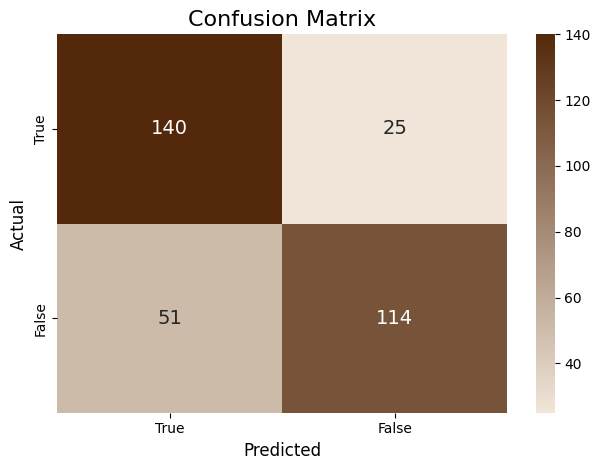

(0.7696969696969697, 0.7329842931937173, 0.8484848484848485)


In [2]:
import pandas as pd
from utils.cross_validation_siamese import CVTrainer

gait_df = pd.read_csv('./datasets/triangulation_gait_features_best_cameras.csv')
cv_trainer = CVTrainer(gait_df)
results = cv_trainer.run_training(n_epochs=20, learning_rate=0.0001, batch_size=4, criterion_type='cosine')
print(results)

In [6]:
import itertools
import logging
import pandas as pd
from utils.cross_validation_siamese import CVTrainer

gait_df = pd.read_csv('./datasets/triangulation_gait_features_best_cameras.csv')
cv_trainer = CVTrainer(dataset=gait_df, log_level=logging.CRITICAL)

n_epochs_values = [5, 10, 15, 20]
learning_rate_values = [1e-2, 1e-3, 1e-4]
batch_size_values = [2, 4, 8, 16, 32, 64]

results = []

param_grid = list(itertools.product(
    n_epochs_values,
    learning_rate_values,
    batch_size_values
))

total_runs = len(param_grid)
results = []

for i, (n_epochs, lr, batch_size) in enumerate(param_grid, start=1):
    print(f"[{i}/{total_runs}] epochs={n_epochs}, lr={lr}, batch_size={batch_size}")
    accuracy, precision, recall = cv_trainer.run_training(
        n_epochs=n_epochs,
        learning_rate=lr,
        batch_size=batch_size,
        show_plot=False,
        criterion_type='cosine',
    )

    results.append({
        "n_epochs": n_epochs,
        "learning_rate": lr,
        "batch_size": batch_size,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall
    })

    print(f"> accuracy={accuracy:.4f} | precision={precision:.4f} | recall={recall:.4f}\n")


[1/72] epochs=5, lr=0.01, batch_size=2
> accuracy=0.7182 | precision=0.7400 | recall=0.6727

[2/72] epochs=5, lr=0.01, batch_size=4
> accuracy=0.6970 | precision=0.7044 | recall=0.6788

[3/72] epochs=5, lr=0.01, batch_size=8
> accuracy=0.7091 | precision=0.7556 | recall=0.6182

[4/72] epochs=5, lr=0.01, batch_size=16
> accuracy=0.7212 | precision=0.7450 | recall=0.6727

[5/72] epochs=5, lr=0.01, batch_size=32
> accuracy=0.7364 | precision=0.7671 | recall=0.6788

[6/72] epochs=5, lr=0.01, batch_size=64
> accuracy=0.7545 | precision=0.7333 | recall=0.8000

[7/72] epochs=5, lr=0.001, batch_size=2
> accuracy=0.7242 | precision=0.7500 | recall=0.6727

[8/72] epochs=5, lr=0.001, batch_size=4
> accuracy=0.7030 | precision=0.6851 | recall=0.7515

[9/72] epochs=5, lr=0.001, batch_size=8
> accuracy=0.7273 | precision=0.7072 | recall=0.7758

[10/72] epochs=5, lr=0.001, batch_size=16
> accuracy=0.6909 | precision=0.6615 | recall=0.7818

[11/72] epochs=5, lr=0.001, batch_size=32
> accuracy=0.6879 |

In [7]:
results_df = pd.DataFrame(results)

ranked_results = results_df.sort_values(by="accuracy", ascending=False).reset_index(drop=True)

print("\nTop 10 parameter sets by accuracy:")
print(ranked_results.head(10))

best_params = ranked_results.iloc[0]
print("\nBest configuration:")
print(best_params)

results_df.to_csv('./results/grid_search_cv_triangulated_best_parameters_cosine.csv')


Top 10 parameter sets by accuracy:
   n_epochs  learning_rate  batch_size  accuracy  precision    recall
0        10         0.0010           8  0.769697   0.824818  0.684848
1         5         0.0100          64  0.754545   0.733333  0.800000
2        15         0.0100          16  0.748485   0.841667  0.612121
3        15         0.0001           2  0.745455   0.734104  0.769697
4         5         0.0100          32  0.736364   0.767123  0.678788
5        10         0.0100           8  0.733333   0.798450  0.624242
6        15         0.0010          16  0.730303   0.775362  0.648485
7         5         0.0010           8  0.727273   0.707182  0.775758
8        10         0.0010          32  0.727273   0.732919  0.715152
9        10         0.0010           4  0.727273   0.777778  0.636364

Best configuration:
n_epochs         10.000000
learning_rate     0.001000
batch_size        8.000000
accuracy          0.769697
precision         0.824818
recall            0.684848
Name: 0, dt

In [8]:
for i in range(5):
    params = ranked_results.iloc[i]
    n_epochs = int(params["n_epochs"])
    lr = params["learning_rate"]
    batch_size = int(params["batch_size"])
    acc_cum, prec_cum, recall_cum = 0, 0, 0
    iterations = 15
    print(f"epochs={n_epochs}, lr={lr}, batch_size={batch_size}")
    for j in range(iterations):
        print(j, end=" | ")

        accuracy, precision, recall = cv_trainer.run_training(
            n_epochs=n_epochs,
            learning_rate=lr,
            batch_size=batch_size,
            show_plot=False,
            criterion_type='cosine',
        )
        acc_cum += accuracy
        prec_cum += precision
        recall_cum += recall

    print(
        f"\naccuracy={acc_cum/iterations:.4f}\n", 
        f"precision={prec_cum/iterations:.4f}\n",
        f"recall={recall_cum/iterations:.4f}\n"
    )

epochs=10, lr=0.001, batch_size=8
0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 | 14 | 
accuracy=0.7166
 precision=0.7606
 recall=0.6335

epochs=5, lr=0.01, batch_size=64
0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 | 14 | 
accuracy=0.7077
 precision=0.6944
 recall=0.7455

epochs=15, lr=0.01, batch_size=16
0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 | 14 | 
accuracy=0.7012
 precision=0.7642
 recall=0.5838

epochs=15, lr=0.0001, batch_size=2
0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 | 14 | 
accuracy=0.7168
 precision=0.6959
 recall=0.7741

epochs=5, lr=0.01, batch_size=32
0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 | 14 | 
accuracy=0.7079
 precision=0.7142
 recall=0.6945



In [9]:
import itertools
import logging
import pandas as pd
from utils.cross_validation_siamese import CVTrainer

gait_df = pd.read_csv('./datasets/gait_features_2.csv')
cv_trainer = CVTrainer(dataset=gait_df, log_level=logging.CRITICAL)

n_epochs_values = [5, 10, 15]
learning_rate_values = [1e-2, 1e-3, 1e-4]
batch_size_values = [2, 4, 8, 16, 32, 64]

results = []

param_grid = list(itertools.product(
    n_epochs_values,
    learning_rate_values,
    batch_size_values
))

total_runs = len(param_grid)
results = []

for i, (n_epochs, lr, batch_size) in enumerate(param_grid, start=1):
    print(f"[{i}/{total_runs}] epochs={n_epochs}, lr={lr}, batch_size={batch_size}")
    accuracy, precision, recall = cv_trainer.run_training(
        n_epochs=n_epochs,
        learning_rate=lr,
        batch_size=batch_size,
        show_plot=False,
        criterion_type='cosine',
    )

    results.append({
        "n_epochs": n_epochs,
        "learning_rate": lr,
        "batch_size": batch_size,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall
    })

    print(f"> accuracy={accuracy:.4f} | precision={precision:.4f} | recall={recall:.4f}\n")


[1/54] epochs=5, lr=0.01, batch_size=2
> accuracy=0.8718 | precision=0.8412 | recall=0.9167

[2/54] epochs=5, lr=0.01, batch_size=4
> accuracy=0.8494 | precision=0.8344 | recall=0.8718

[3/54] epochs=5, lr=0.01, batch_size=8
> accuracy=0.8686 | precision=0.8324 | recall=0.9231

[4/54] epochs=5, lr=0.01, batch_size=16
> accuracy=0.8910 | precision=0.8675 | recall=0.9231

[5/54] epochs=5, lr=0.01, batch_size=32
> accuracy=0.8654 | precision=0.8132 | recall=0.9487

[6/54] epochs=5, lr=0.01, batch_size=64
> accuracy=0.8526 | precision=0.8481 | recall=0.8590

[7/54] epochs=5, lr=0.001, batch_size=2
> accuracy=0.8718 | precision=0.8671 | recall=0.8782

[8/54] epochs=5, lr=0.001, batch_size=4
> accuracy=0.8654 | precision=0.8353 | recall=0.9103

[9/54] epochs=5, lr=0.001, batch_size=8
> accuracy=0.8782 | precision=0.8430 | recall=0.9295

[10/54] epochs=5, lr=0.001, batch_size=16
> accuracy=0.8494 | precision=0.8114 | recall=0.9103

[11/54] epochs=5, lr=0.001, batch_size=32
> accuracy=0.8526 |

In [10]:
results_df = pd.DataFrame(results)

ranked_results = results_df.sort_values(by="accuracy", ascending=False).reset_index(drop=True)

print("\nTop 10 parameter sets by accuracy:")
print(ranked_results.head(10))

best_params = ranked_results.iloc[0]
print("\nBest configuration:")
print(best_params)

results_df.to_csv('./results/grid_search_cv_mocap_all_features_cosine.csv')


Top 10 parameter sets by accuracy:
   n_epochs  learning_rate  batch_size  accuracy  precision    recall
0        15          0.001          16  0.913462   0.916129  0.910256
1        15          0.010           8  0.910256   0.915584  0.903846
2        10          0.001          32  0.907051   0.889571  0.929487
3        10          0.010           8  0.903846   0.879518  0.935897
4        15          0.001           2  0.897436   0.860465  0.948718
5        10          0.010          64  0.894231   0.872727  0.923077
6        10          0.001           8  0.894231   0.886792  0.903846
7         5          0.010          16  0.891026   0.867470  0.923077
8        10          0.001           2  0.891026   0.871951  0.916667
9        15          0.010          16  0.887821   0.875776  0.903846

Best configuration:
n_epochs         15.000000
learning_rate     0.001000
batch_size       16.000000
accuracy          0.913462
precision         0.916129
recall            0.910256
Name: 0, dt

In [11]:
  import itertools
import logging
import pandas as pd
from utils.cross_validation_siamese import CVTrainer

gait_df = pd.read_csv('./datasets/gait_features_2.csv')
cv_trainer = CVTrainer(dataset=gait_df, log_level=logging.CRITICAL)

n_epochs_values = [5, 10, 15]
learning_rate_values = [1e-2, 1e-3, 1e-4]
batch_size_values = [2, 4, 8, 16, 32, 64]

results = []

param_grid = list(itertools.product(
    n_epochs_values,
    learning_rate_values,
    batch_size_values
))

total_runs = len(param_grid)
results = []

for i, (n_epochs, lr, batch_size) in enumerate(param_grid, start=1):
    print(f"[{i}/{total_runs}] epochs={n_epochs}, lr={lr}, batch_size={batch_size}")
    accuracy, precision, recall = cv_trainer.run_training(
        n_epochs=n_epochs,
        learning_rate=lr,
        batch_size=batch_size,
        show_plot=False,
        criterion_type='euclidean',
    )

    results.append({
        "n_epochs": n_epochs,
        "learning_rate": lr,
        "batch_size": batch_size,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall
    })

    print(f"> accuracy={accuracy:.4f} | precision={precision:.4f} | recall={recall:.4f}\n")


[1/54] epochs=5, lr=0.01, batch_size=2
> accuracy=0.7244 | precision=0.8125 | recall=0.5833

[2/54] epochs=5, lr=0.01, batch_size=4
> accuracy=0.7724 | precision=0.9474 | recall=0.5769

[3/54] epochs=5, lr=0.01, batch_size=8
> accuracy=0.8173 | precision=0.9024 | recall=0.7115

[4/54] epochs=5, lr=0.01, batch_size=16
> accuracy=0.8109 | precision=0.8819 | recall=0.7179

[5/54] epochs=5, lr=0.01, batch_size=32
> accuracy=0.8237 | precision=0.9469 | recall=0.6859

[6/54] epochs=5, lr=0.01, batch_size=64
> accuracy=0.8077 | precision=0.8582 | recall=0.7372

[7/54] epochs=5, lr=0.001, batch_size=2
> accuracy=0.8654 | precision=0.9318 | recall=0.7885

[8/54] epochs=5, lr=0.001, batch_size=4
> accuracy=0.8654 | precision=0.9318 | recall=0.7885

[9/54] epochs=5, lr=0.001, batch_size=8
> accuracy=0.9006 | precision=0.9562 | recall=0.8397

[10/54] epochs=5, lr=0.001, batch_size=16
> accuracy=0.8846 | precision=0.9615 | recall=0.8013

[11/54] epochs=5, lr=0.001, batch_size=32
> accuracy=0.9167 |

In [13]:
results_df = pd.DataFrame(results)

ranked_results = results_df.sort_values(by="accuracy", ascending=False).reset_index(drop=True)

print("\nTop 10 parameter sets by accuracy:")
print(ranked_results.head(10))

best_params = ranked_results.iloc[0]
print("\nBest configuration:")
print(best_params)

results_df.to_csv('./results/grid_search_cv_mocap_all_features_polynomial.csv')


Top 10 parameter sets by accuracy:
   n_epochs  learning_rate  batch_size  accuracy  precision    recall
0         5         0.0010          32  0.916667   0.933333  0.897436
1         5         0.0010           8  0.900641   0.956204  0.839744
2        15         0.0001           4  0.891026   0.906667  0.871795
3        10         0.0001           2  0.887821   0.923077  0.846154
4         5         0.0010          16  0.884615   0.961538  0.801282
5        15         0.0001           2  0.878205   0.868750  0.891026
6        15         0.0001           8  0.871795   0.886667  0.852564
7         5         0.0001           2  0.868590   0.902098  0.826923
8        10         0.0010          16  0.865385   0.938462  0.782051
9         5         0.0010           4  0.865385   0.931818  0.788462

Best configuration:
n_epochs          5.000000
learning_rate     0.001000
batch_size       32.000000
accuracy          0.916667
precision         0.933333
recall            0.897436
Name: 0, dt